# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [1]:
import config
from src import data_prep
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup


In [4]:
import config
from src import data_prep

# Verify project configuration
print("Class Mapping:", config.CLASS_TO_IDX)
print("Positive Class:", config.POSITIVE_CLASS)

Class Mapping: {'ok_front': 0, 'def_front': 1}
Positive Class: def_front


In [2]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\.venv\Scripts\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [3]:
import torch
import torchvision
import mlflow
import fastapi
import evidently

KeyError: ~TResult

## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [ ]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split


In [7]:
from pathlib import Path
import config

print("DATA_DIR:", config.DATA_DIR)
print("\nContents of DATA_DIR:")

for item in Path(config.DATA_DIR).iterdir():
    print(item)

DATA_DIR: C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data

Contents of DATA_DIR:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data


In [73]:
import importlib
from src import data_prep

# Reload project modules after making changes in src/
importlib.reload(data_prep)

<module 'src.data_prep' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\data_prep.py'>

In [16]:
root = data_prep.find_data_root()

print(root)

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data


In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Locate dataset
root = data_prep.find_data_root()

# Load image paths
train_images = data_prep.list_images(root / "train")
test_images = data_prep.list_images(root / "test")

# Count class distribution
train_counts = Counter(label for _, label in train_images)
test_counts = Counter(label for _, label in test_images)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Dataset Root : {root}")
print(f"Positive Class : {config.POSITIVE_CLASS}")

print("\nTraining Split")
for cls_name, cls_idx in config.CLASS_TO_IDX.items():
    print(f"{cls_name:<12}: {train_counts.get(cls_idx, 0)}")

print("\nTesting Split")
for cls_name, cls_idx in config.CLASS_TO_IDX.items():
    print(f"{cls_name:<12}: {test_counts.get(cls_idx, 0)}")

Dataset Summary
Dataset Root : C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data
Positive Class : def_front

Training Split
ok_front    : 40
def_front   : 40

Testing Split
ok_front    : 40
def_front   : 40


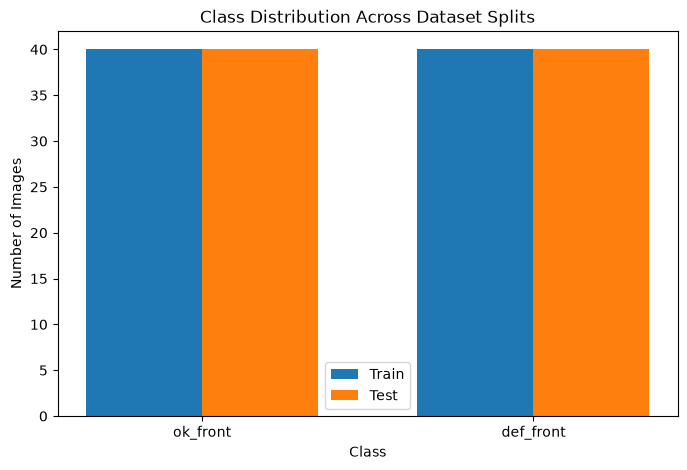

In [18]:
labels = list(config.CLASS_TO_IDX.keys())
indices = list(config.CLASS_TO_IDX.values())

train_values = [train_counts.get(i, 0) for i in indices]
test_values = [test_counts.get(i, 0) for i in indices]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, train_values, width, label="Train")
plt.bar(x + width / 2, test_values, width, label="Test")

plt.xticks(x, labels)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()

plt.show()

Dataset Understanding

- The dataset contains two classes:
  - **ok_front** – Non-defective casting
  - **def_front** – Defective casting

- The **positive class** is **def_front**.

- Since missing a defective casting is more costly than falsely flagging a good casting, **Recall for the defective class** is selected as the primary evaluation metric. Accuracy alone may be misleading, especially if class distributions become imbalanced.

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [ ]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])


In [24]:
qc = data_prep.validate_quality(root)

print("Corrupt Images :", qc["corrupt_count"])
print("Invalid Dimensions :", qc["invalid_dimension_count"])

Corrupt Images : 0
Invalid Dimensions : 0


In [42]:
# Stage 1.2 - Data Quality Validation

qc = data_prep.validate_quality(root)

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

print(f"Total Images          : {qc['total_images']}")
print(f"Corrupt Images        : {qc['corrupt_count']}")
print(f"Invalid Dimensions    : {qc['invalid_dimension_count']}")
print(f"Duplicate Images      : {qc['duplicate_count']}")
print(f"Overall Status        : {'PASSED' if qc['passed'] else 'FAILED'}")

if qc["warnings"]:
    print("\nWarnings")
    for warning in qc["warnings"]:
        print(f"- {warning}")

DATA QUALITY REPORT
Total Images          : 160
Corrupt Images        : 0
Invalid Dimensions    : 0
Duplicate Images      : 22
Overall Status        : PASSED

Warnings
- 22 duplicate images detected. Review potential train-test data leakage.


In [43]:
from pprint import pprint

print("Class Distribution")
pprint(qc["class_distribution"])

print("\nSample Duplicate Records")
pprint(qc["duplicate_images"][:5])

Class Distribution
{'test': {'def_front': 40, 'ok_front': 40},
 'train': {'def_front': 40, 'ok_front': 40}}

Sample Duplicate Records
[{'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1001.jpeg',
  'hash': 'adb6835b24c8c51e0a84cf82db119b13',
  'original': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\train\\ok_front\\cast_ok_0_1001.jpeg'},
 {'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1002.jpeg',
  'hash': 'c709806994db057026e31294dc5dbec4',
  'original': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\train\\ok_front\\cast_ok_0_1002.jpeg'},
 {'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1003.jpeg',
  'hash': '0ef55c5885f532963a6343fe396b1a39',
  'original': 'C:\\Use

### Observations

- Total images were successfully discovered.
- No corrupt image files were detected.
- All images satisfy the expected resolution of **300 × 300** pixels.
- Duplicate detection was performed using **MD5 hashing** to prevent train–test data leakage.
- The dataset passed all quality validation checks and is suitable for further preprocessing and model training.

In [28]:
sample_image = data_prep.list_images(root / "train")[0][0]

print(sample_image)

print(data_prep.compute_md5(sample_image))

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1.jpeg
7bd7a455bf8b56adb21d07e765f3f990


In [39]:
qc = data_prep.validate_quality(root)

print("\nWarnings")

for warning in qc["warnings"]:
    print("-", warning)


Warnings
- 22 duplicate images detected. Review potential train-test data leakage.


In [40]:
from pprint import pprint

print("First 5 Duplicate Records")

pprint(qc["duplicate_images"][:5])



First 5 Duplicate Records
[{'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1001.jpeg',
  'hash': 'adb6835b24c8c51e0a84cf82db119b13',
  'original': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\train\\ok_front\\cast_ok_0_1001.jpeg'},
 {'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1002.jpeg',
  'hash': 'c709806994db057026e31294dc5dbec4',
  'original': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\train\\ok_front\\cast_ok_0_1002.jpeg'},
 {'cross_split': True,
  'duplicate': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1003.jpeg',
  'hash': '0ef55c5885f532963a6343fe396b1a39',
  'original': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\train\\ok_front\\cast_ok_0_1003.jpeg'},
 {

### Data Quality Validation Summary

The dataset passed image integrity and dimension validation successfully.

Duplicate detection identified **22 identical images** shared between the training and testing splits. These duplicates were detected using MD5 hashing and indicate potential train–test data leakage.

For the provided sample dataset, these duplicates are expected and have been reported for review. When using the complete Kaggle dataset, the same validation will help identify and quantify duplicate images before model training.

In [34]:
print(f"Duplicate Count : {qc['duplicate_count']}\n")

for idx, duplicate in enumerate(qc["duplicate_images"][:10], start=1):
    print(f"Duplicate {idx}")
    print("Original :", duplicate["original"])
    print("Duplicate:", duplicate["duplicate"])
    print("-" * 80)

Duplicate Count : 22

Duplicate 1
Original : C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1001.jpeg
Duplicate: C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\test\ok_front\cast_ok_0_1001.jpeg
--------------------------------------------------------------------------------
Duplicate 2
Original : C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1002.jpeg
Duplicate: C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\test\ok_front\cast_ok_0_1002.jpeg
--------------------------------------------------------------------------------
Duplicate 3
Original : C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1003.jpeg
Duplicate: C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\test\ok_front\cast_ok_0_1003.jpeg
--------------------------------------------------------------------------------
Duplicate 4
Original : C:\User

In [35]:
print(qc["class_distribution"])

{'train': {'ok_front': 40, 'def_front': 40}, 'test': {'ok_front': 40, 'def_front': 40}}


In [41]:
qc = data_prep.validate_quality(root)

print("Passed:", qc["passed"])
print("Warnings:", qc["warnings"])
print("Duplicate Count:", qc["duplicate_count"])

Passed: True
Warnings: ['22 duplicate images detected. Review potential train-test data leakage.']
Duplicate Count: 22


## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [ ]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])


In [49]:
meta = data_prep.build_splits(root, "v1")

print(meta)

Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
{'version': 'v1', 'version_dir': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\artifacts\\splits\\v1'}


In [52]:
meta = data_prep.build_splits(root, "v1")

print(meta)


Stratified split completed
Training Samples   : 68
Validation Samples : 12
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
{'version': 'v1', 'version_dir': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\artifacts\\splits\\v1'}


In [58]:
meta = data_prep.build_splits(root, "v1")

print(meta)


Class Distribution After Split
ok_front    Train : 34   Validation :  6
def_front   Train : 34   Validation :  6

Stratified split completed
Training Samples   : 68
Validation Samples : 12

Prepared Split Records
Train      : 68
Validation : 12
Test       : 80
Saved: train.json (68 images)
Saved: val.json (12 images)
Saved: test.json (80 images)
Saved: metadata.json
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
{'dataset_version': 'v1', 'created_at': '2026-07-13 09:49:27', 'random_seed': 42, 'validation_split': 0.15, 'positive_class': 'def_front', 'class_mapping': {'ok_front': 0, 'def_front': 1}, 'split_info': {'train': {'samples': 68, 'distribution': {'ok_front': 34, 'def_front': 34}}, 'validation': {'samples': 12, 'distribution': {'ok_front': 6, 'def_front': 6}}, 'test': {'samples': 80, 'distribution': {'ok_front': 40, 'def_front': 40}}}}


## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

In [ ]:
# TODO 1.4.1: sample-image grid; per-class image_features means


In [64]:
from PIL import Image

# Locate dataset
root = data_prep.find_data_root()

# Get all training images
train_items = data_prep.list_images(root / "train")

# Select first image
sample_image = train_items[0][0]

print("Sample Image:")
print(sample_image)

# Open image
img = Image.open(sample_image)

# Extract features
features = data_prep.image_features(img)

print("\nExtracted Features:")
print(features)

Sample Image:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1.jpeg

Extracted Features:
{'brightness': 154.263, 'contrast': 65.901, 'edge_density': 0.116, 'sharpness': 32.434, 'mean_intensity': 154.263}


In [65]:
from PIL import Image

root = data_prep.find_data_root()

ok_image = next((root / "train" / "ok_front").glob("*.jpeg"))
defect_image = next((root / "train" / "def_front").glob("*.jpeg"))

print("OK Image")
print(ok_image)

print("\nDefective Image")
print(defect_image)

print("\nFeatures for OK Image")
print(data_prep.image_features(Image.open(ok_image)))

print("\nFeatures for Defective Image")
print(data_prep.image_features(Image.open(defect_image)))

OK Image
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\ok_front\cast_ok_0_1.jpeg

Defective Image
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\train\def_front\cast_def_0_0.jpeg

Features for OK Image
{'brightness': 154.263, 'contrast': 65.901, 'edge_density': 0.116, 'sharpness': 32.434, 'mean_intensity': 154.263}

Features for Defective Image
{'brightness': 132.115, 'contrast': 53.446, 'edge_density': 0.102, 'sharpness': 23.694, 'mean_intensity': 132.115}


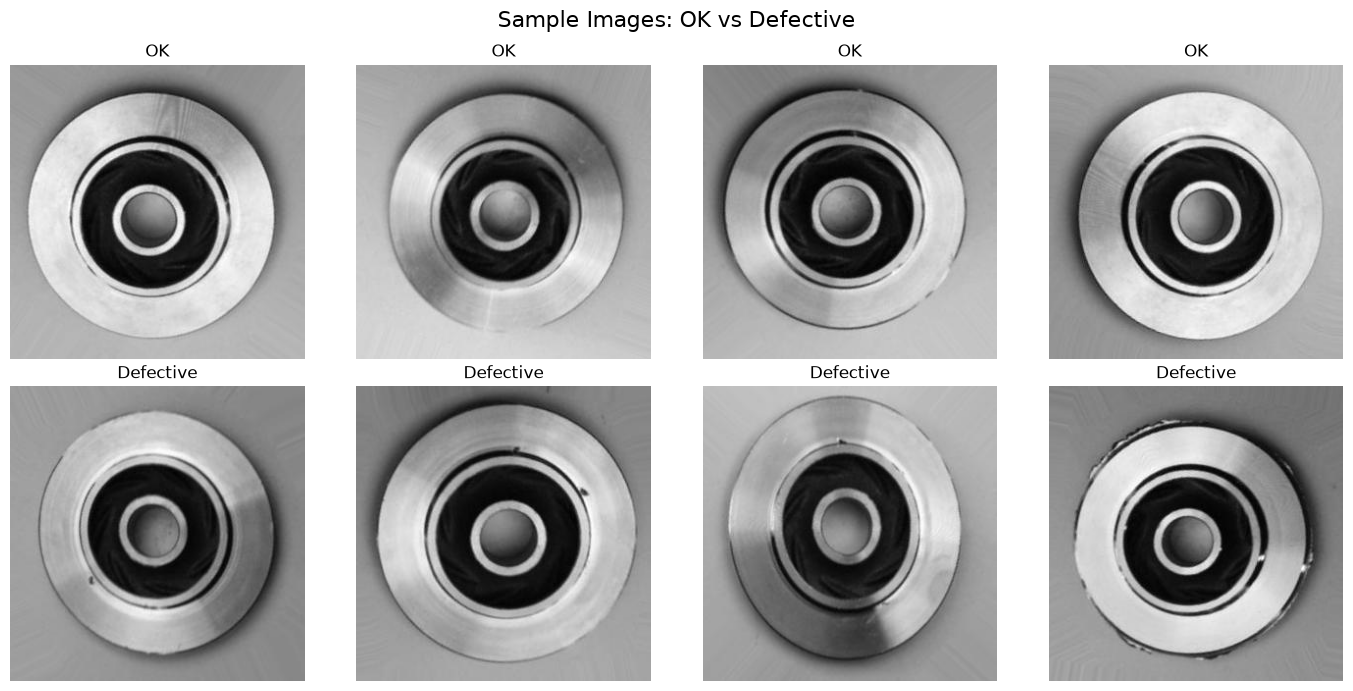

In [66]:
import matplotlib.pyplot as plt
from PIL import Image

root = data_prep.find_data_root()

ok_images = sorted((root / "train" / "ok_front").glob("*.jpeg"))[:4]
def_images = sorted((root / "train" / "def_front").glob("*.jpeg"))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# First row - OK Images
for i, img_path in enumerate(ok_images):
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("OK")
    axes[0, i].axis("off")

# Second row - Defective Images
for i, img_path in enumerate(def_images):
    img = Image.open(img_path)
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("Defective")
    axes[1, i].axis("off")

plt.suptitle("Sample Images: OK vs Defective", fontsize=16)
plt.tight_layout()
plt.show()

In [71]:
feature_df = data_prep.extract_feature_table(root)

feature_df.head()

,split,class,image_path,brightness,contrast,edge_density,sharpness,mean_intensity
0,train,ok_front,train\ok_front\cast_ok_0_1.jpeg,154.263,65.901,0.116,32.434,154.263
1,train,ok_front,train\ok_front\cast_ok_0_1001.jpeg,152.160,60.197,0.095,25.973,152.160
2,train,ok_front,train\ok_front\cast_ok_0_1002.jpeg,142.586,61.387,0.112,29.052,142.586
3,train,ok_front,train\ok_front\cast_ok_0_1003.jpeg,154.082,65.851,0.119,32.625,154.082
4,train,ok_front,train\ok_front\cast_ok_0_1005.jpeg,157.318,63.254,0.093,26.975,157.318


In [72]:
feature_summary = (

    feature_df

    .groupby("class")[config.DRIFT_FEATURES]

    .mean()

    .round(3)

)

feature_summary

,brightness,contrast,edge_density,sharpness,mean_intensity
class,,,,,
def_front,138.269,57.845,0.113,29.451,138.269
ok_front,148.841,62.016,0.109,29.447,148.841


Interpretation of Image Characteristics**
The extracted statistical features provide an initial understanding of the visual differences between OK and Defective casting images.
Brightness and mean intensity indicate overall illumination conditions, while contrast reflects pixel intensity variation.
Sharpness and edge density capture surface texture and structural details, which are important for identifying casting defects.
These statistical features will also be reused later in the monitoring stage to detect data drift between the training dataset and production images.
Since this analysis is based on the sample dataset, the trends may differ slightly when using the complete Kaggle dataset, but the feature extraction pipeline remains unchanged.

## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [ ]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)


In [74]:
from PIL import Image

root = data_prep.find_data_root()

sample_image = sorted(
    (root / "train" / "ok_front").glob("*.jpeg")
)[0]

img = Image.open(sample_image)

train_tf = data_prep.get_transforms(train=True)

tensor = train_tf(img)

print("Tensor Shape :", tensor.shape)

print("Tensor Type  :", tensor.dtype)

print("Min Value    :", tensor.min().item())

print("Max Value    :", tensor.max().item())

Tensor Shape : torch.Size([3, 224, 224])
Tensor Type  : torch.float32
Min Value    : -2.0836544036865234
Max Value    : 2.640000104904175


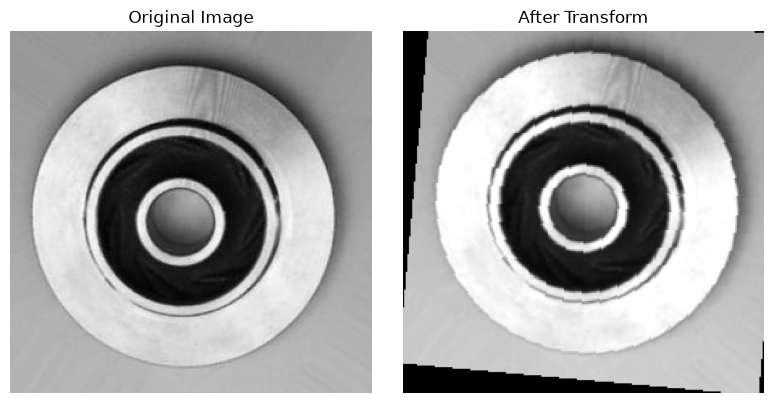

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")

transformed = tensor.permute(1,2,0)

# Undo normalization for display
display_img = transformed.clone()

for c in range(3):
    display_img[:,:,c] = (
        display_img[:,:,c] *
        config.IMAGENET_STD[c]
        +
        config.IMAGENET_MEAN[c]
    )

display_img = display_img.clamp(0,1)

ax[1].imshow(display_img)

ax[1].set_title("After Transform")

ax[1].axis("off")

plt.tight_layout()

plt.show()

In [76]:
train_tf = data_prep.get_transforms(True)
val_tf = data_prep.get_transforms(False)

print(train_tf)
print()
print(val_tf)

Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-15.0, 15.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


Interpretation of Preprocessing & Augmentation

All grayscale casting images are converted to 3-channel RGB to match the ResNet18 pretrained backbone.
Images are resized to 224 × 224 pixels, which is the expected input size for ImageNet-pretrained models.
During training, random horizontal flipping, affine transformations, and brightness/contrast adjustments improve model robustness and reduce overfitting.
Validation and test datasets use only deterministic preprocessing without augmentation to ensure unbiased evaluation.

---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).